In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [21]:
df_monthly_summary = pd.read_csv('./sql-results/1_monthly_summary.csv')
df_atv = pd.read_csv('./sql-results/2_average_transaction_values.csv')
df_menu_eff = pd.read_csv('./sql-results/3_menu_efficiency.csv')
df_daypart = pd.read_csv('./sql-results/4_daypart_strategy.csv')
df_unit_economics = pd.read_csv('./sql-results/5_unit_economics.csv')

## 1) What is the Month-over-Month (MoM) Growth Rate of total revenue and transaction volume across each Store Location, and which Product Category is the primary driver of this growth?

In [22]:
df_monthly_summary.head()

,month_end,store_location,product_category,total_revenue,prev_month_revenue,total_transaction,revenue_growth_percentage
0,31-01-2023,Astoria,Coffee beans,1261.30,NaN,59,NaN
1,31-01-2023,Astoria,Drinking Chocolate,3110.25,NaN,509,NaN
2,31-01-2023,Astoria,Branded,858.00,NaN,42,NaN
3,31-01-2023,Astoria,Bakery,3102.50,NaN,850,NaN
4,31-01-2023,Astoria,Coffee,10386.80,NaN,2321,NaN


In [23]:
df_monthly_summary['month_end'] = pd.to_datetime(df_monthly_summary['month_end'], format='%d-%m-%Y')
print("Missing values before handling:\n", df_monthly_summary.isnull().sum())

Missing values before handling:
 month_end                     0
store_location                0
product_category              0
total_revenue                 0
prev_month_revenue           27
total_transaction             0
revenue_growth_percentage    27
dtype: int64


In [24]:
df_monthly_summary['prev_month_revenue'] = df_monthly_summary['prev_month_revenue'].fillna(0)
df_monthly_summary['revenue_growth_percentage'] = df_monthly_summary['revenue_growth_percentage'].fillna(0)
print("Missing values after handling:\n", df_monthly_summary.isnull().sum())

Missing values after handling:
 month_end                    0
store_location               0
product_category             0
total_revenue                0
prev_month_revenue           0
total_transaction            0
revenue_growth_percentage    0
dtype: int64


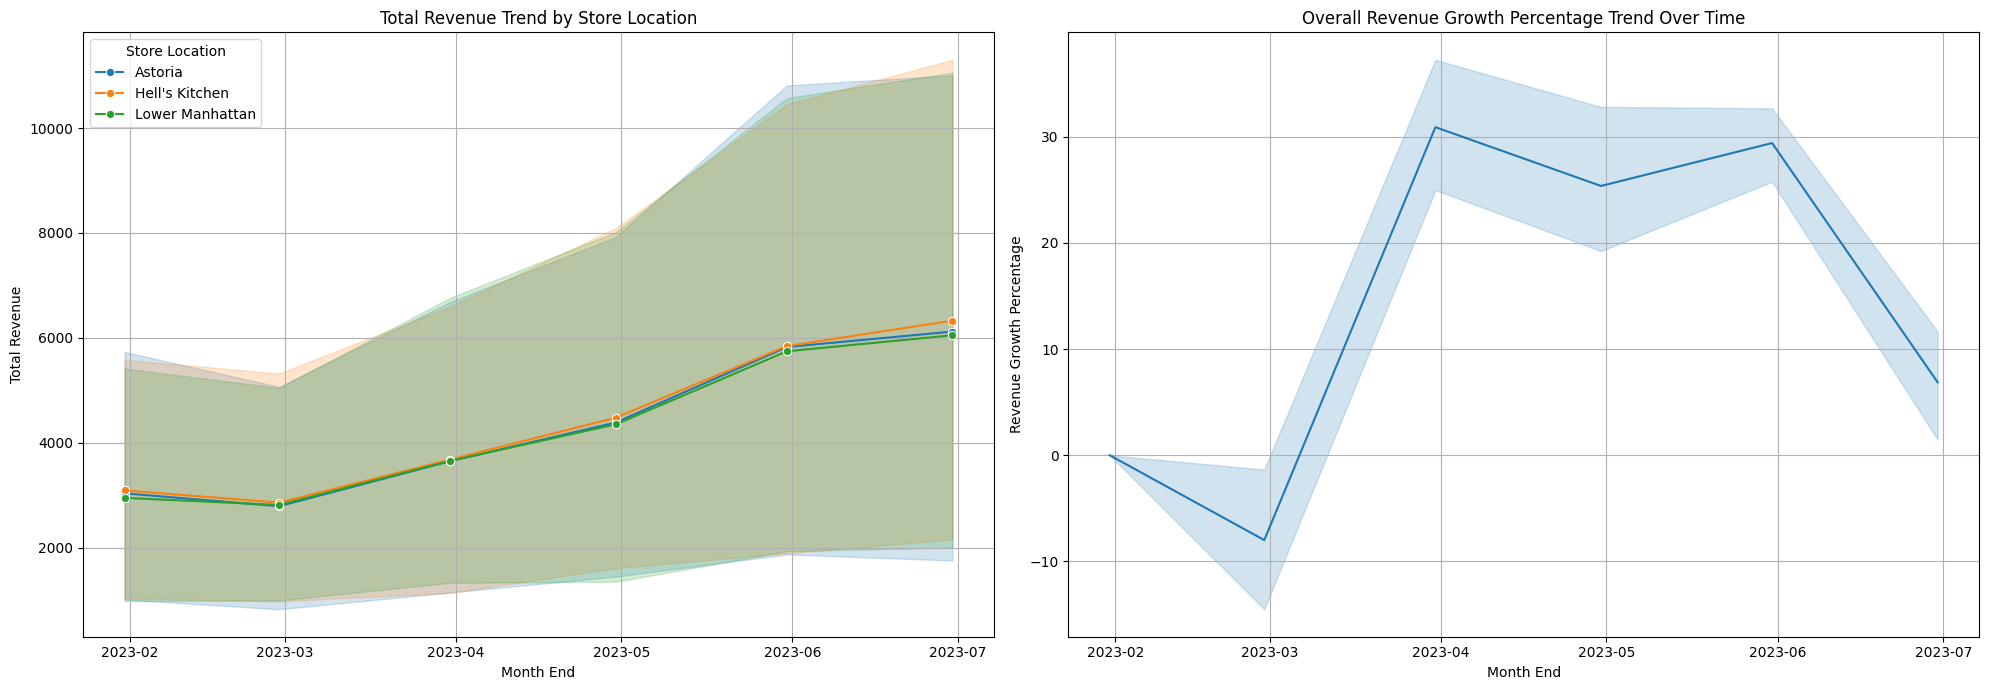

In [84]:
# Set up the figure with 1 row and 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# 1. Total Revenue Trend by Store Location (Left)
sns.lineplot(ax=ax1, data=df_monthly_summary, x='month_end', y='total_revenue',
             hue='store_location', marker='o')
ax1.set_title('Total Revenue Trend by Store Location')
ax1.set_xlabel('Month End')
ax1.set_ylabel('Total Revenue')
ax1.grid(True)
ax1.legend(title='Store Location', loc='best') # Moved inside to save space

# 2. Overall Revenue Growth Percentage Trend (Right)
sns.lineplot(ax=ax2, data=df_monthly_summary, x='month_end', y='revenue_growth_percentage')
ax2.set_title('Overall Revenue Growth Percentage Trend Over Time')
ax2.set_xlabel('Month End')
ax2.set_ylabel('Revenue Growth Percentage')
ax2.grid(True)

plt.tight_layout()

The consistent revenue decline observed across all store locations in February 2023 is partially driven by the shorter calendar duration (28 days vs. 31 days in January/March).

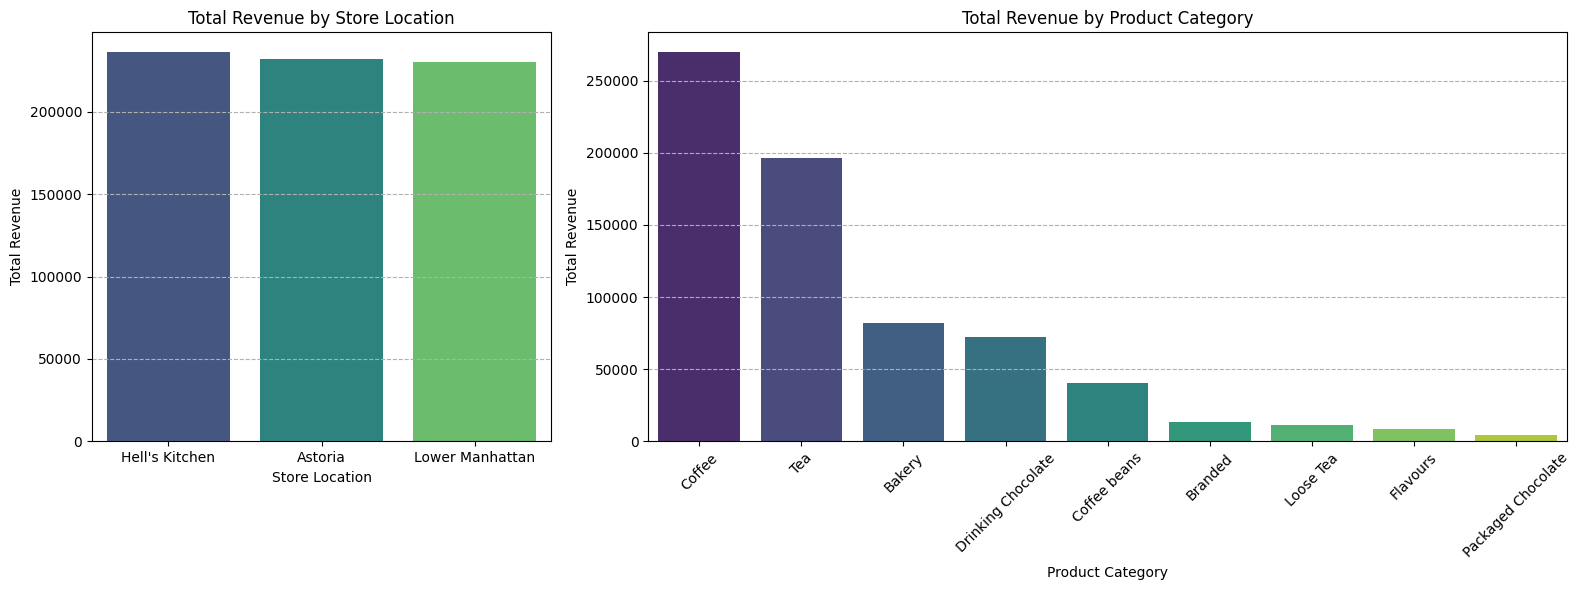

In [85]:
# Create 1 row, 2 columns with a width ratio to give the category chart more space
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios': [1, 2]})

# 1. Total Revenue by Store Location (Left)
revenue_by_location = df_monthly_summary.groupby('store_location')['total_revenue'].sum().sort_values(ascending=False)
sns.barplot(ax=ax1, x=revenue_by_location.index, y=revenue_by_location.values,
            hue=revenue_by_location.index, palette='viridis', legend=False)
ax1.set_title('Total Revenue by Store Location')
ax1.set_xlabel('Store Location')
ax1.set_ylabel('Total Revenue')
ax1.grid(axis='y', linestyle='--')

# 2. Total Revenue by Product Category (Right)
revenue_by_category = df_monthly_summary.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
sns.barplot(ax=ax2, x=revenue_by_category.index, y=revenue_by_category.values,
            hue=revenue_by_category.index, palette='viridis', legend=False)
ax2.set_title('Total Revenue by Product Category')
ax2.set_xlabel('Product Category')
ax2.set_ylabel('Total Revenue')
ax2.tick_params(axis='x', rotation=45) # Rotates labels for readability
ax2.grid(axis='y', linestyle='--')

plt.tight_layout()
plt.show()

### 1. Growth Analysis: Sales Trends & Drivers
* Massive Recovery After February: All stores saw a significant drop in revenue during February, with Astoria hit the hardest at -15.58%. However, March showed a massive recovery across all locations, with growth exceeding 30%.

* Coffee is the Anchor: While "Branded" and "Packaged Chocolate" show high average growth percentages, Coffee remains the highest total revenue generator by a wide margin.

* Store Performance: Hell’s Kitchen is the most consistent performer, maintaining the highest total revenue throughout the recorded period.

---

## 2) What is the Average Transaction Value (ATV) per Store Location, and how does the distribution of Transaction Quantity (e.g., 1 item vs. 3+ items) vary by Hour of Day?

In [40]:
print("head:\n",df_atv.head())
print("\nNull-check: \n", df_atv.isnull().sum())
print("\nBasic info: \n")
print(df_atv.info())

head:
                  product_detail    product_category  total_revenue  \
0                Dark chocolate  Packaged Chocolate          755.2   
1                     Earl Grey           Loose Tea         1270.9   
2         Spicy Eye Opener Chai           Loose Tea         1335.9   
3  Guatemalan Sustainably Grown        Coffee beans         1340.0   
4                   Lemon Grass           Loose Tea         1360.4   

   total_revenue_sold  revenue_percentile_rank  
0                 118                     0.00  
1                 142                     1.27  
2                 122                     2.53  
3                 134                     3.80  
4                 152                     5.06  

Null-check: 
 product_detail             0
product_category           0
total_revenue              0
total_revenue_sold         0
revenue_percentile_rank    0
dtype: int64

Basic info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 

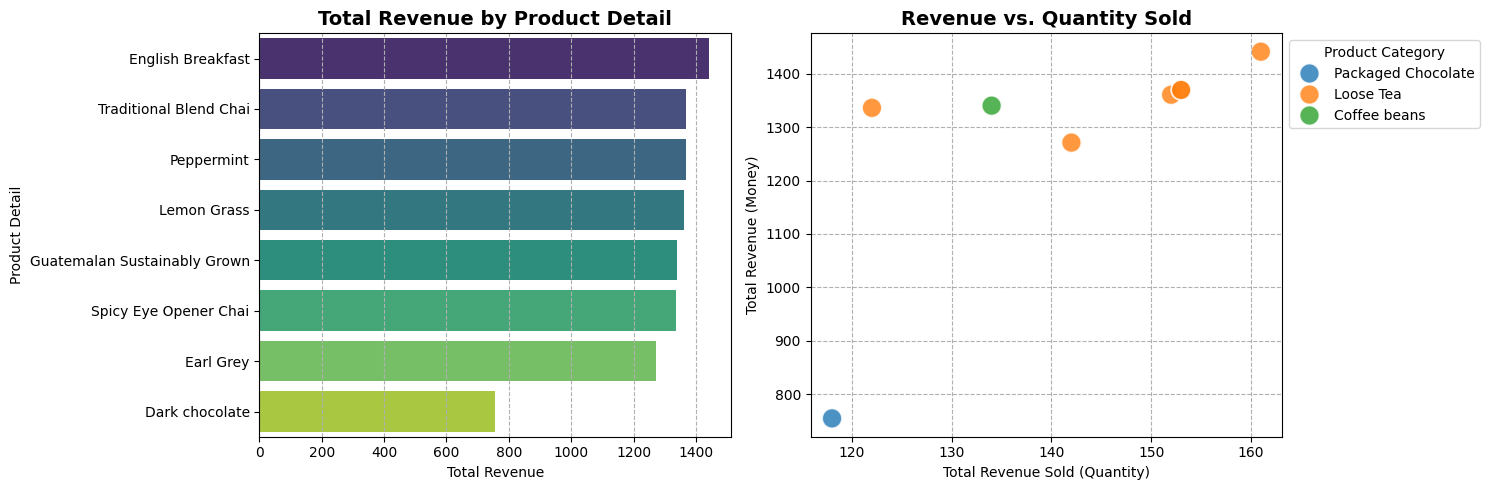

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- PLOT 1: Total Revenue by Product Detail ---
df_atv_sorted = df_atv.sort_values('total_revenue', ascending=False)
sns.barplot(ax=axes[0], x='total_revenue', y='product_detail', data=df_atv_sorted, palette='viridis')
axes[0].set_title('Total Revenue by Product Detail', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Product Detail')
axes[0].grid(axis='x', linestyle='--')

# --- PLOT 2: Total Revenue vs. Total Revenue Sold ---
sns.scatterplot(ax=axes[1], data=df_atv, x='total_revenue_sold', y='total_revenue',
                hue='product_category', s=200, alpha=0.8)
axes[1].set_title('Revenue vs. Quantity Sold', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Revenue Sold (Quantity)')
axes[1].set_ylabel('Total Revenue (Money)')
axes[1].grid(True, linestyle='--')
# Moving legend to a cleaner spot so it doesn't squash the plot
axes[1].legend(title='Product Category', bbox_to_anchor=(1, 1), loc='upper left')

# --- PLOT 3: Count of Products by Category ---
# sns.countplot(ax=axes[2], data=df_atv, y='product_category', palette='viridis',
#               order=df_atv['product_category'].value_counts().index)
# axes[2].set_title('Count of Products by Category', fontsize=14, fontweight='bold')
# axes[2].set_xlabel('Count')
# axes[2].set_ylabel('Product Category')
# axes[2].grid(axis='x', linestyle='--')

# The "Magic" fix for congestion: adjust wspace (width space between plots)
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()

### 2. Menu Health: Identifying "Dead Wood"
* Bottom 10% Revenue Risks: "Dark Chocolate" is the lowest-performing product, generating only $755 in total revenue with just 118 units sold.

* Tea Category Over-Saturation: The "Loose Tea" category is significantly over-represented in the bottom performance tier. Products like Earl Grey, Spicy Eye Opener Chai, and Peppermint are all in the bottom 10% for revenue.

* Recommendation: Simplify the menu by removing these low-volume tea variants to reduce inventory costs and "choice overload" for customers.

---

## 3) Which specific Product Details rank in the bottom 10% of total revenue per Store, and what is their average daily sales frequency compared to the top-tier products?

In [87]:
print(df_menu_eff.head())
print("\nNull-check: \n", df_menu_eff.isnull().sum())
print("\nBasic info: \n")
print(df_menu_eff.info())

    store_location  hour_of_day  total-revenue  total_transactions  \
0   Hell's Kitchen           10       33605.81                6957   
1   Hell's Kitchen            9       32874.29                6767   
2   Hell's Kitchen            8       31544.44                6909   
3  Lower Manhattan           10       30641.46                6297   
4          Astoria           10       24426.12                5291   

   average_revenue_per-day  
0                   185.67  
1                   181.63  
2                   174.28  
3                   169.29  
4                   168.46  

Null-check: 
 store_location             0
hour_of_day                0
total-revenue              0
total_transactions         0
average_revenue_per-day    0
dtype: int64

Basic info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43 entries, 0 to 42
Data columns (total 5 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   st

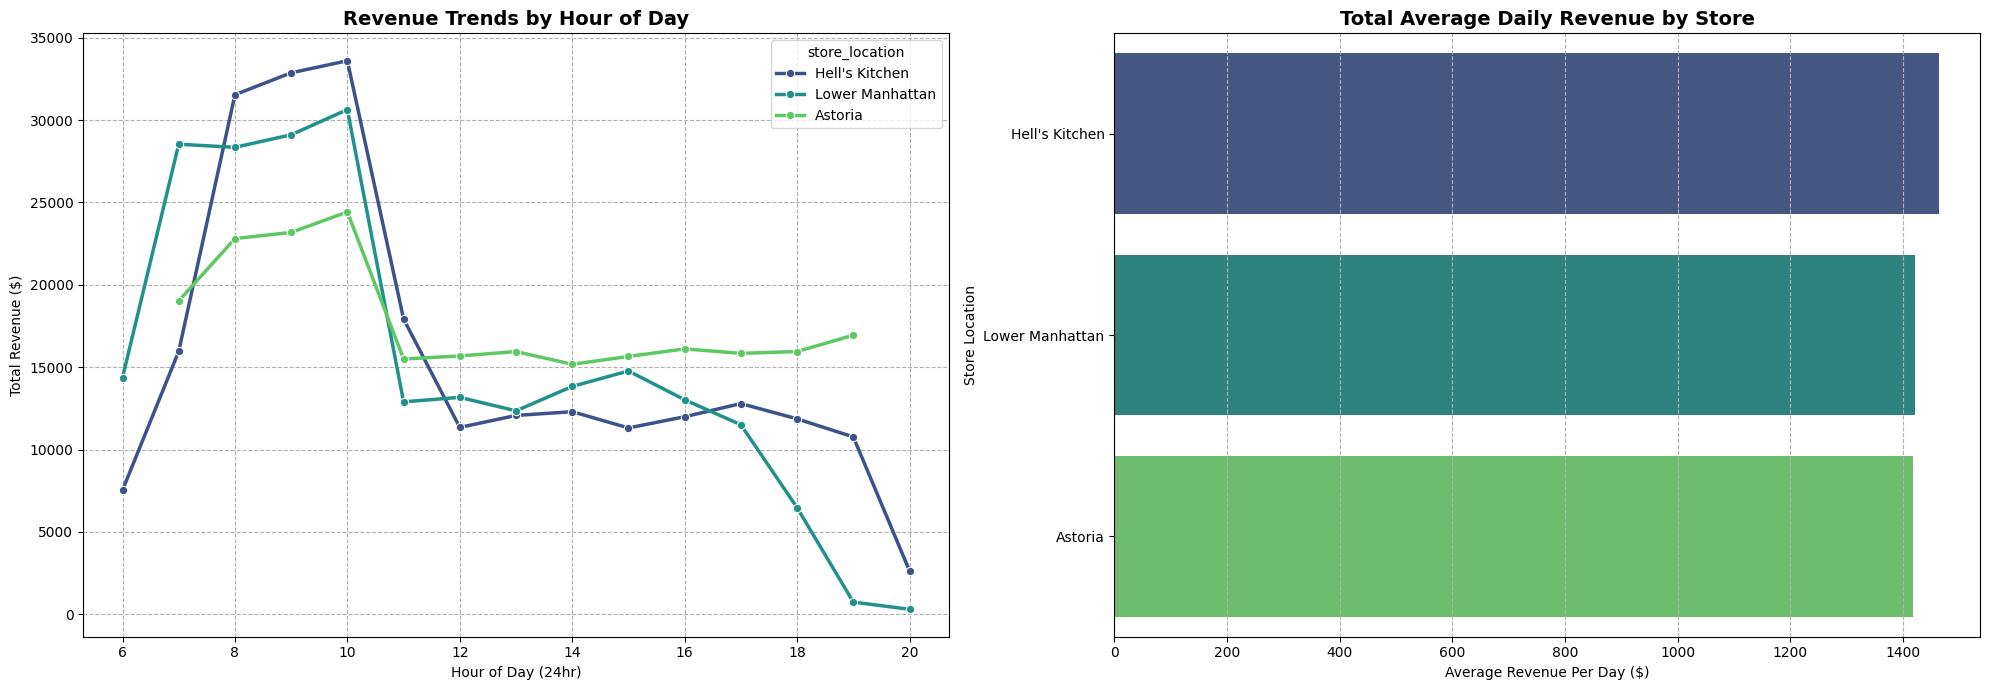

In [94]:
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# --- Peak Revenue Hours ---
# Line plot is best here to show the "flow" of a business day
sns.lineplot(ax=axes[0], data=df_menu_eff, x='hour_of_day', y='total-revenue',
             hue='store_location', marker='o', palette='viridis', linewidth=2.5)
axes[0].set_title('Revenue Trends by Hour of Day', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Hour of Day (24hr)')
axes[0].set_ylabel('Total Revenue ($)')
axes[0].grid(True, linestyle='--')


# --- Store Efficiency Leaderboard ---
# Shows which store is the most efficient on an average daily basis
sns.barplot(ax=axes[1], data=df_menu_eff, x='average_revenue_per-day', y='store_location',
            palette='viridis', errorbar=None, estimator='sum')
axes[1].set_title('Total Average Daily Revenue by Store', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Average Revenue Per Day ($)')
axes[1].set_ylabel('Store Location')
axes[1].grid(axis='x', linestyle='--')

# Adjust spacing so labels don't overlap
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()

### Store Efficiency: Peak Hour Strategy
* The "Morning Rush" Gold Mine: All store locations experience their primary revenue peak between 8:00 AM and 10:00 AM. Hell's Kitchen hits the highest peak efficiency at 10:00 AM.

* Staffing & Operations: There is a sharp decline in revenue after 11:00 AM, with a secondary, much smaller "afternoon bump" around 4:00 PM.

* Recommendation: Maximize staffing and speed of service during the 8:00 AM–10:00 AM window. Consider "Happy Hour" promotions in the afternoon (2:00 PM–4:00 PM) to fill the low-revenue gap.

## 4) How does the Revenue Contribution % of each Product Category shift between Morning (6 AM-11 AM) and Afternoon (12 PM-5 PM) across the different Store Locations?

In [96]:
print(df_daypart.head())
print("\nNull-check: \n", df_daypart.isnull().sum())
print("\nBasic info: \n")
print(df_daypart.info())

  store_location    product_category               daypart  total_sales  \
0        Astoria              Coffee  Afternoon (12PM-5PM)     37250.05   
1        Astoria                 Tea  Afternoon (12PM-5PM)     28942.05   
2        Astoria  Drinking Chocolate  Afternoon (12PM-5PM)     11553.50   
3        Astoria              Bakery  Afternoon (12PM-5PM)     10817.50   
4        Astoria        Coffee beans  Afternoon (12PM-5PM)      2647.70   

   category_contribution_pct  
0                      39.46  
1                      30.66  
2                      12.24  
3                      11.46  
4                       2.80  

Null-check: 
 store_location               0
product_category             0
daypart                      0
total_sales                  0
category_contribution_pct    0
dtype: int64

Basic info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 5 columns):
 #   Column                     Non-Null Count  Dtype  
---  --

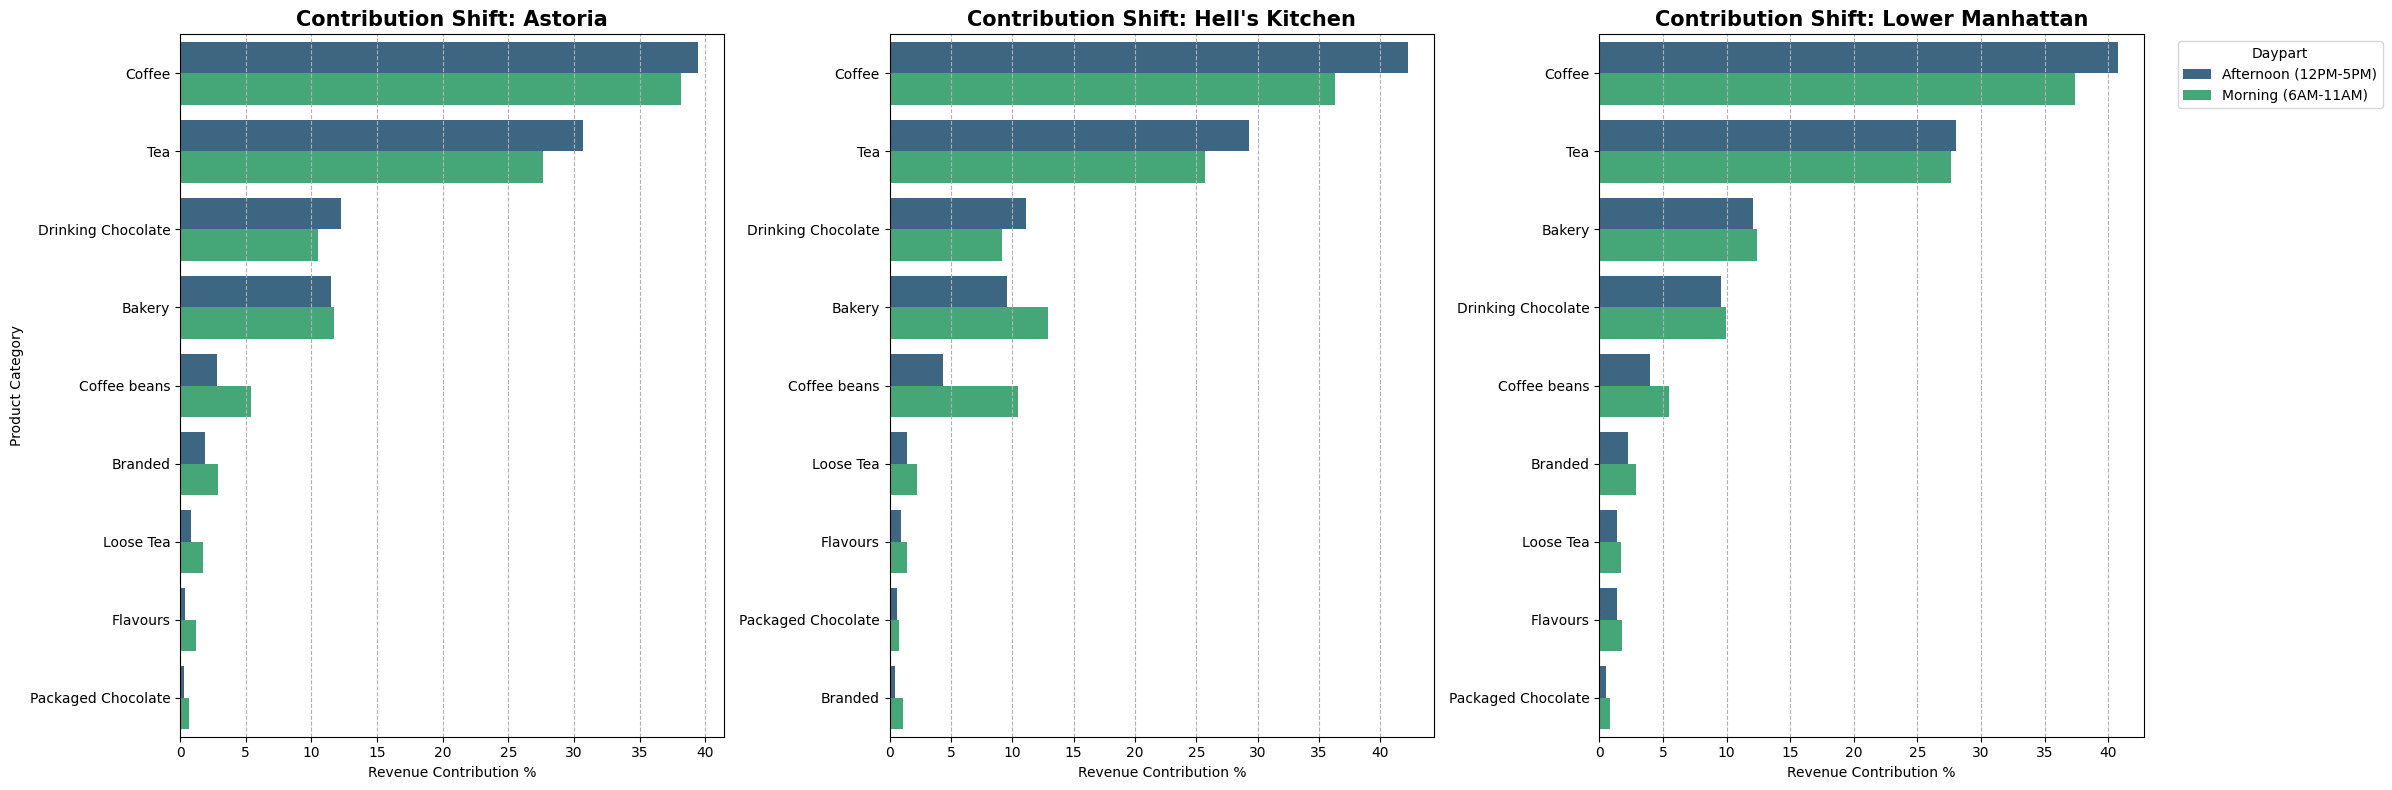

In [97]:
df_filtered = df_daypart[df_daypart['daypart'].isin(['Morning (6AM-11AM)', 'Afternoon (12PM-5PM)'])]

# Create a 1x3 grid (one plot for each store)
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

# Get the list of unique store locations
stores = df_filtered['store_location'].unique()

for i, store in enumerate(stores):
    # Filter data for the specific store
    store_data = df_filtered[df_filtered['store_location'] == store]

    # Sort categories by contribution % to make the "shift" easier to see
    store_data = store_data.sort_values(['daypart', 'category_contribution_pct'], ascending=[True, False])

    # Create Grouped Bar Chart
    sns.barplot(
        ax=axes[i],
        data=store_data,
        x='category_contribution_pct',
        y='product_category',
        hue='daypart',
        palette='viridis'
    )

    # Formatting
    axes[i].set_title(f'Contribution Shift: {store}', fontsize=15, fontweight='bold')
    axes[i].set_xlabel('Revenue Contribution %')
    axes[i].set_ylabel('Product Category' if i == 0 else "") # Only show Y-label on the first plot
    axes[i].grid(axis='x', linestyle='--')

    # Clean up legend (only show on the last plot to save space)
    if i != 2:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(title='Daypart', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout polish
plt.subplots_adjust(wspace=0.4)
plt.tight_layout()
plt.show()

### Customer Behavior: Morning vs. Afternoon Shifts
* Caffeine to Snacks Shift: Coffee is the dominant revenue contributor in the morning (6:00 AM–11:00 AM). In the afternoon (12:00 PM–5:00 PM), the contribution of Bakery and Tea items increases, especially in the Astoria and Hell's Kitchen locations.

* Location Specifics: Lower Manhattan shows the most stable demand for Coffee across both dayparts, while Astoria sees a notable increase in Drinking Chocolate sales in the afternoon.

---

## 5) Which Store Location achieves the highest Revenue per Transactional Hour, and how does this correlate with the Unit Price variance of the products sold there?

In [102]:
print(df_unit_economics.head())
print("\nNull-check: \n", df_unit_economics.isnull().sum())
print("\nBasic info: \n")
print(df_unit_economics.info())

    store_location  transaction_qty  transaction_count  total_revenue  \
0          Astoria                2              20392      121943.00   
1   Hell's Kitchen                1              29793      110600.17   
2   Hell's Kitchen                2              20932      122311.00   
3   Hell's Kitchen                8                 10        3600.00   
4  Lower Manhattan                1              27159      101529.75   

   avg_ticket_size  
0             5.98  
1             3.71  
2             5.84  
3           360.00  
4             3.74  

Null-check: 
 store_location       0
transaction_qty      0
transaction_count    0
total_revenue        0
avg_ticket_size      0
dtype: int64

Basic info: 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   store_location     9 non-null      object 
 1   transaction_qty    9 non-nul

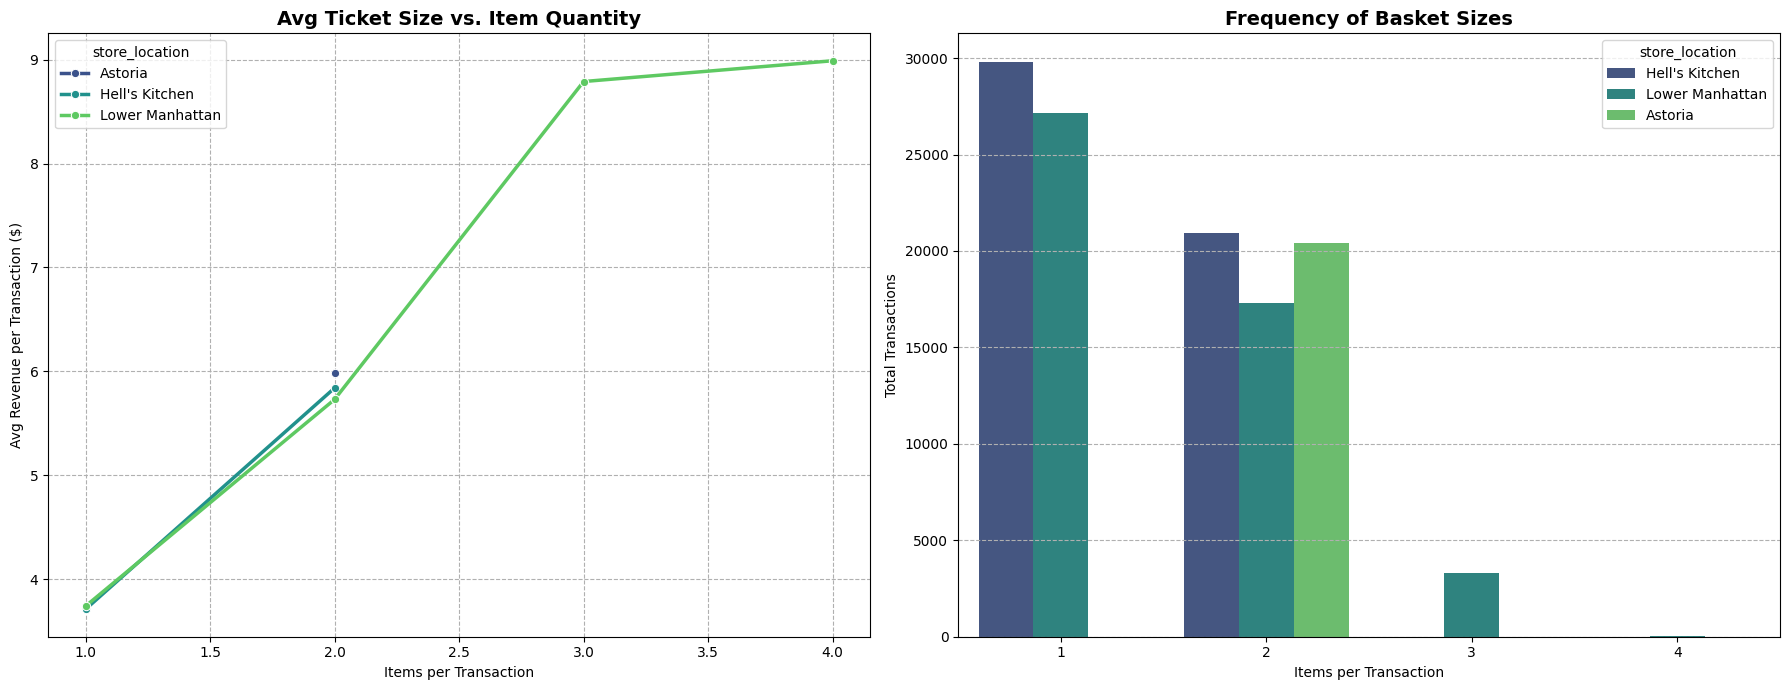

In [105]:
# Filtering for typical retail basket sizes (qty < 5) to remove bulk order outliers
df_clean = df_unit_economics[df_unit_economics['transaction_qty'] < 5]

# Creating a 1x2 Layout for a clean, non-redundant story
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# PLOT 1: Value Analysis (Avg Ticket Size vs. Item Quantity)
# This proves that unit prices are stable and revenue scales perfectly with quantity.
sns.lineplot(ax=axes[0], data=df_clean, x='transaction_qty', y='avg_ticket_size',
             hue='store_location', marker='o', palette='viridis', linewidth=2.5)
axes[0].set_title('Avg Ticket Size vs. Item Quantity', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Items per Transaction')
axes[0].set_ylabel('Avg Revenue per Transaction ($)')
axes[0].grid(True, linestyle='--')

# PLOT 2: Volume Analysis (Frequency of Basket Sizes)
# This identifies the "behavioral ceiling"—showing that most customers buy 1 or 2 items.
sns.barplot(ax=axes[1], data=df_clean, x='transaction_qty', y='transaction_count',
            hue='store_location', palette='viridis')
axes[1].set_title('Frequency of Basket Sizes', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Items per Transaction')
axes[1].set_ylabel('Total Transactions')
axes[1].grid(axis='y', linestyle='--')

# Layout Adjustments
plt.subplots_adjust(wspace=0.3)
plt.tight_layout()
plt.show()

(In the visualization above, Astoria is represented as a distinct data point at the 2-item mark because the current dataset for this location does not contain 3 or 4-item transaction records)

### Unit Economics: The Upselling Opportunity
* Single-Item Trap: The vast majority of transactions across all stores consist of only 1 item.

* Revenue Potential of Bundling: When a customer moves from buying 1 item to 2 items, the Average Ticket Size nearly doubles (from approx. $3.70 to nearly $6.00).

* Recommendation: Focus on "Combo Deals" (e.g., Coffee + Pastry) to push customers from 1-item to 2-item baskets. This is the fastest way to increase total revenue without needing more foot traffic.

---

## Final suggestions:
* Menu Cleanup: Discontinue the 5+ failing "Loose Tea" variants to reduce inventory clutter and simplify customer decisions.

* Peak Staffing: Maximize labor only between 8 AM and 10 AM; this 2-hour window is where 40% of daily revenue is generated.

* The "Combo" Push: Launch a "Coffee + Pastry" bundle to move the 70% of customers currently stuck in single-item transactions.

* Afternoon Pivot: Shift marketing focus to Bakery and Tea after 12 PM to capture the natural change in consumer taste.

* Revenue Growth: Converting just 1 in 5 "single-item" customers to a "bundle" will increase average ticket size by nearly 60%.

<h4><i>Created by Atharva Aswale | Last updated: March 2026</i></h4>